In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════
# SOFTMAX NEDİR VE kNN'DEN FARKI NE?
# ══════════════════════════════════════════════════════
#
# kNN'de:
#   - Eğitim yok, sadece veriyi ezberle
#   - Tahmin için tüm eğitim verisiyle mesafe hesapla
#   - 5000 görüntü varsa 5000 mesafe hesaplarsın → YAVAŞ
#
# Softmax'ta:
#   - Bir W matrisi öğren (3072 x 10 boyutunda)
#   - Tahmin için sadece W @ x yap → ÇOK HIZLI
#   - Eğitim bittikten sonra eğitim verisine gerek yok!
#
# Yani Softmax bir şeyler "öğrenir", kNN sadece "ezberler"
#
# CIFAR-10 için:
#   - 10 sınıf var (kedi, köpek, araba...)
#   - Her görüntü 3072 piksel
#   - W shape: (10, 3072) — her sınıf için bir ağırlık vektörü
# ══════════════════════════════════════════════════════

X = np.array([
    [1.0, 2.0, 3.0],   # 1. görüntü — kedi
    [4.0, 5.0, 6.0],   # 2. görüntü — köpek
    [7.0, 8.0, 9.0],   # 3. görüntü — kuş
    [2.0, 4.0, 6.0],   # 4. görüntü — kedi
])
y = np.array([0, 1, 2, 0])  # 0=kedi, 1=köpek, 2=kuş

N, D = X.shape           # N=4 görüntü, D=3 piksel
C = len(np.unique(y))    # C=3 sınıf

print(f"Görüntü sayısı (N): {N}")
print(f"Piksel sayısı (D): {D}")
print(f"Sınıf sayısı (C): {C}")

Görüntü sayısı (N): 4
Piksel sayısı (D): 3
Sınıf sayısı (C): 3


In [ ]:
# ══════════════════════════════════════════════════════
# W MATRİSİ NEDİR?
# ══════════════════════════════════════════════════════
#
# W = ağırlık matrisi — Softmax'ın "beyni"
#
# Shape: (C, D) = (sınıf sayısı, piksel sayısı)
# Bizim örneğimizde: (3, 3)
# Gerçekte CIFAR-10: (10, 3072)
#
# W'nun her satırı bir sınıfı temsil eder:
#   W[0] = kedi için ağırlıklar
#   W[1] = köpek için ağırlıklar
#   W[2] = kuş için ağırlıklar
#
# Başta rastgele başlatılır, eğitimle öğrenilir
# ══════════════════════════════════════════════════════

np.random.seed(0)  # her çalıştırmada aynı sonuç için

W = np.random.randn(C, D) * 0.01  # küçük rastgele sayılar
print("W matrisi:")
print(W)
print("W shape:", W.shape)  # (3 sınıf, 3 piksel)

# Şimdi skor hesaplayalım
# skor = X @ W.T
# (4, 3) @ (3, 3) = (4, 3)
# Her görüntü için 3 skor — her sınıf için bir tane
skorlar = X @ W.T
print("\nSkorlar:")
print(skorlar)
print("Skorlar shape:", skorlar.shape)  # (4 görüntü, 3 sınıf)
print("\nYorum: skorlar[0] = 1. görüntünün 3 sınıf için skorları")
print("skorlar[0]:", skorlar[0])

W matrisi:
[[ 0.01764052  0.00400157  0.00978738]
 [ 0.02240893  0.01867558 -0.00977278]
 [ 0.00950088 -0.00151357 -0.00103219]]
W shape: (3, 3)

Skorlar:
[[0.05500581 0.03044176 0.00337717]
 [0.14929423 0.12437695 0.02424255]
 [0.24358266 0.21831215 0.04510792]
 [0.11001161 0.06088351 0.00675435]]
Skorlar shape: (4, 3)

Yorum: skorlar[0] = 1. görüntünün 3 sınıf için skorları
skorlar[0]: [0.05500581 0.03044176 0.00337717]


In [ ]:
# ══════════════════════════════════════════════════════
# SOFTMAX FONKSİYONU — SKORLARI OLASILIĞA ÇEVİR
# ══════════════════════════════════════════════════════
#
# Problem: skorlar [-2.5, 1.3, 0.8] gibi herhangi bir sayı olabilir
# Biz olasılık istiyoruz: 0 ile 1 arasında, toplamı 1
#
# Softmax formülü:
#   olasılık[i] = e^skor[i] / toplam(e^skor)
#
# Neden e (üstel fonksiyon)?
#   - Negatif skorları pozitife çevirir
#   - Büyük skorları daha da büyütür (farkı belirginleştirir)
#
# Numerik stabilite için küçük bir hile:
#   Her skordan max'ı çıkar → sonuç değişmez ama taşma olmaz
#   e^1000 → sonsuz olabilir, e^(1000-1000) = e^0 = 1 → güvenli
# ══════════════════════════════════════════════════════

# Her satırdan max'ı çıkar (numerik stabilite)
skorlar_stable = skorlar - np.max(skorlar, axis=1, keepdims=True)
print("Stabil skorlar:")
print(skorlar_stable)

# e üssünü al
e_skorlar = np.exp(skorlar_stable)
print("\ne^skorlar:")
print(e_skorlar)

# Her satırı kendi toplamına böl
olasiliklar = e_skorlar / np.sum(e_skorlar, axis=1, keepdims=True)
print("\nOlasılıklar:")
print(olasiliklar)

print("\nHer satırın toplamı:", np.sum(olasiliklar, axis=1))
# Hepsi 1.0 olmalı!

print("\nYorum:")
print(f"1. görüntü → kedi: %{olasiliklar[0,0]*100:.1f}, köpek: %{olasiliklar[0,1]*100:.1f}, kuş: %{olasiliklar[0,2]*100:.1f}")
print(f"Tahmin: sınıf {np.argmax(olasiliklar[0])} ", end="")
print("(kedi)" if np.argmax(olasiliklar[0])==0 else "(köpek)" if np.argmax(olasiliklar[0])==1 else "(kuş)")

Stabil skorlar:
[[ 0.         -0.02456405 -0.05162863]
 [ 0.         -0.02491728 -0.12505169]
 [ 0.         -0.02527051 -0.19847474]
 [ 0.         -0.0491281  -0.10325727]]

e^skorlar:
[[1.         0.97573519 0.94968148]
 [1.         0.97539059 0.88245129]
 [1.         0.97504612 0.81998048]
 [1.         0.95205916 0.90189492]]

Olasılıklar:
[[0.34183165 0.33353717 0.32463119]
 [0.34991439 0.34130321 0.3087824 ]
 [0.35777835 0.34885039 0.29337126]
 [0.35039106 0.33359302 0.31601592]]

Her satırın toplamı: [1. 1. 1. 1.]

Yorum:
1. görüntü → kedi: %34.2, köpek: %33.4, kuş: %32.5
Tahmin: sınıf 0 (kedi)


In [ ]:
# ══════════════════════════════════════════════════════
# LOSS FONKSİYONU — TAHMİN NE KADAR YANLIŞ?
# ══════════════════════════════════════════════════════
#
# Loss = modelin ne kadar yanlış olduğunu ölçen sayı
#   loss küçük → model iyi tahmin ediyor
#   loss büyük → model kötü tahmin ediyor
#
# Softmax loss formülü:
#   loss = -log(doğru sınıfın olasılığı)
#
# Neden -log?
#   olasılık=1.0 → -log(1.0) = 0    → mükemmel, loss yok
#   olasılık=0.5 → -log(0.5) = 0.69 → fena değil
#   olasılık=0.1 → -log(0.1) = 2.30 → kötü
#   olasılık=0.01→ -log(0.01)= 4.60 → çok kötü
#
# Tüm görüntüler için ortalama alırız → tek bir loss sayısı
# ══════════════════════════════════════════════════════

# y = [0, 1, 2, 0] — doğru sınıflar
# Her görüntü için doğru sınıfın olasılığını al
dogru_olasiliklar = olasiliklar[np.arange(N), y]
print("Doğru sınıfların olasılıkları:", dogru_olasiliklar)
# y[0]=0 → 1. görüntünün kedi olasılığı
# y[1]=1 → 2. görüntünün köpek olasılığı
# y[2]=2 → 3. görüntünün kuş olasılığı
# y[3]=0 → 4. görüntünün kedi olasılığı

# -log al
log_olasiliklar = -np.log(dogru_olasiliklar)
print("Her görüntü için loss:", log_olasiliklar)

# Ortalama al → tek bir loss sayısı
loss = np.mean(log_olasiliklar)
print(f"\nToplam loss: {loss:.4f}")
print(f"\nYorum: Rastgele tahmin için beklenen loss = {np.log(C):.4f}")
print(f"(3 sınıf varsa rastgele %33 olasılık → -log(1/3) = {np.log(3):.4f})")
print(f"Bizim loss'umuz buna yakın çünkü W henüz hiç öğrenmedi!")

Doğru sınıfların olasılıkları: [0.34183165 0.34130321 0.29337126 0.35039106]
Her görüntü için loss: [1.07343692 1.07498403 1.22631637 1.04870543]

Toplam loss: 1.1059

Yorum: Rastgele tahmin için beklenen loss = 1.0986
(3 sınıf varsa rastgele %33 olasılık → -log(1/3) = 1.0986)
Bizim loss'umuz buna yakın çünkü W henüz hiç öğrenmedi!


In [ ]:
# ══════════════════════════════════════════════════════
# GRADIENT — W'YU HANGİ YÖNDE DEĞİŞTİRELİM?
# ══════════════════════════════════════════════════════
#
# Gradient = loss'un W'ya göre türevi
# "W'yu biraz değiştirirsem loss ne kadar değişir?"
#
# Softmax gradient formülü çok güzel:
#   - Tüm sınıfların olasılığından başla
#   - Sadece DOĞRU sınıfın olasılığından 1 çıkar
#   - X ile çarp → gradient hazır!
#
# Sezgi:
#   Doğru sınıf için: olasılık - 1
#     olasılık 0.9 ise → 0.9-1 = -0.1 (az değiştir, iyi gidiyoruz)
#     olasılık 0.1 ise → 0.1-1 = -0.9 (çok değiştir, kötü gidiyoruz)
#   Yanlış sınıflar için: olasılık - 0 = olasılık
#     (bu sınıfların skorunu azalt)
# ══════════════════════════════════════════════════════

# Gradient matrisini olasılıklardan başlat
grad = olasiliklar.copy()   # shape: (4, 3)
print("Başlangıç (olasılıklar):")
print(grad)

# Doğru sınıflardan 1 çıkar
grad[np.arange(N), y] -= 1
print("\nDoğru sınıflardan 1 çıkardıktan sonra:")
print(grad)

# N'e böl (ortalama için)
grad /= N
print("\nN'e böldükten sonra (final gradient):")
print(grad)

# W için gradient: grad.T @ X
grad_W = grad.T @ X    # (3, 4) @ (4, 3) = (3, 3)
print("\nW için gradient (grad_W):")
print(grad_W)
print("grad_W shape:", grad_W.shape)  # W ile aynı shape olmalı!

Başlangıç (olasılıklar):
[[0.34183165 0.33353717 0.32463119]
 [0.34991439 0.34130321 0.3087824 ]
 [0.35777835 0.34885039 0.29337126]
 [0.35039106 0.33359302 0.31601592]]

Doğru sınıflardan 1 çıkardıktan sonra:
[[-0.65816835  0.33353717  0.32463119]
 [ 0.34991439 -0.65869679  0.3087824 ]
 [ 0.35777835  0.34885039 -0.70662874]
 [-0.64960894  0.33359302  0.31601592]]

N'e böldükten sonra (final gradient):
[[-0.16454209  0.08338429  0.0811578 ]
 [ 0.0874786  -0.1646742   0.0771956 ]
 [ 0.08944459  0.0872126  -0.17665718]
 [-0.16240223  0.08339826  0.07900398]]

W için gradient (grad_W):
[[ 0.48667994  0.17425657 -0.1381668 ]
 [ 0.20197219  0.37469139  0.54741059]
 [-0.68865213 -0.54894796 -0.40924379]]
grad_W shape: (3, 3)


In [ ]:
# ══════════════════════════════════════════════════════
# W'YU GÜNCELLE — GRADIENT DESCENT
# ══════════════════════════════════════════════════════
#
# Gradient bize "loss bu yönde artıyor" diyor
# Biz loss'u azaltmak istiyoruz
# O yüzden gradient'in TAM TERSİ yönde gidiyoruz
#
# Güncelleme formülü:
#   W = W - learning_rate * gradient
#
# Learning rate (lr) nedir?
#   Ne kadar büyük adım atacağımızı belirler
#   lr çok büyük → adım çok büyük → loss azalmak yerine artar
#   lr çok küçük → adım çok küçük → çok yavaş öğrenir
#   Genelde 0.01 veya 0.001 kullanılır
# ══════════════════════════════════════════════════════

lr = 0.1  # learning rate

print(f"Eski W:\n{W}")
print(f"\nEski loss: {loss:.4f}")

# W'yu güncelle
W_yeni = W - lr * grad_W

# Yeni W ile loss hesapla
skorlar_yeni = X @ W_yeni.T
e_yeni = np.exp(skorlar_yeni - np.max(skorlar_yeni, axis=1, keepdims=True))
olasiliklar_yeni = e_yeni / np.sum(e_yeni, axis=1, keepdims=True)
dogru_yeni = olasiliklar_yeni[np.arange(N), y]
loss_yeni = -np.mean(np.log(dogru_yeni))

print(f"\nYeni W:\n{W_yeni}")
print(f"\nYeni loss: {loss_yeni:.4f}")
print(f"\nLoss azaldı mı? {loss_yeni < loss}")
print(f"Ne kadar azaldı: {loss - loss_yeni:.6f}")

Eski W:
[[ 0.01764052  0.00400157  0.00978738]
 [ 0.02240893  0.01867558 -0.00977278]
 [ 0.00950088 -0.00151357 -0.00103219]]

Eski loss: 1.1059

Yeni W:
[[-0.03102747 -0.01342408  0.02360406]
 [ 0.00221171 -0.01879356 -0.06451384]
 [ 0.0783661   0.05338122  0.03989219]]

Yeni loss: 1.1238

Loss azaldı mı? False
Ne kadar azaldı: -0.017911


In [ ]:
# ══════════════════════════════════════════════════════
# LEARNING RATE'İN ETKİSİ
# ══════════════════════════════════════════════════════
#
# lr çok büyük → adım çok büyük → hedefi geçiyoruz
# lr çok küçük → adım çok küçük → çok yavaş
# lr doğru     → loss düzenli azalır
#
# Farklı lr değerlerini deneyelim
# ══════════════════════════════════════════════════════

for lr in [0.001, 0.01, 0.1, 1.0]:
    W_test = W - lr * grad_W

    skorlar_test = X @ W_test.T
    e_test = np.exp(skorlar_test - np.max(skorlar_test, axis=1, keepdims=True))
    olasiliklar_test = e_test / np.sum(e_test, axis=1, keepdims=True)
    loss_test = -np.mean(np.log(olasiliklar_test[np.arange(N), y]))

    azaldi_mi = "✅ azaldı" if loss_test < loss else "❌ arttı"
    print(f"lr={lr:.3f} → loss={loss_test:.4f}  {azaldi_mi}")

lr=0.001 → loss=1.1042  ✅ azaldı
lr=0.010 → loss=1.0906  ✅ azaldı
lr=0.100 → loss=1.1238  ❌ arttı
lr=1.000 → loss=6.0022  ❌ arttı


Epoch   0: loss = 1.1059
Epoch  10: loss = 1.0451
Epoch  20: loss = 1.0109
Epoch  30: loss = 0.9792
Epoch  40: loss = 0.9497
Epoch  50: loss = 0.9223
Epoch  60: loss = 0.8969
Epoch  70: loss = 0.8733
Epoch  80: loss = 0.8513
Epoch  90: loss = 0.8308


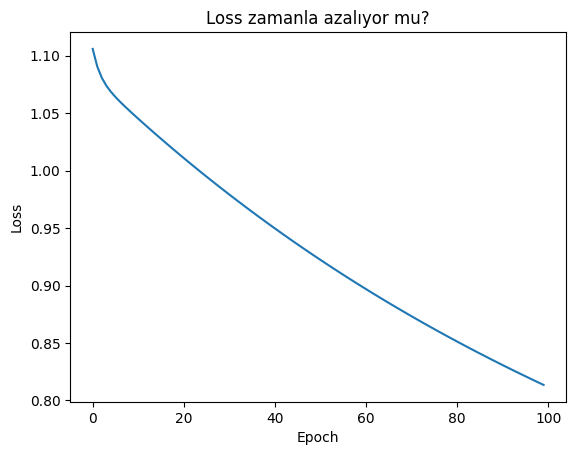

In [ ]:
# ══════════════════════════════════════════════════════
# EĞİTİM DÖNGÜSÜ — W'YU TEKRAR TEKRAR GÜNCELLE
# ══════════════════════════════════════════════════════
#
# Tek bir güncelleme yetmez
# W'yu yüzlerce, binlerce kez güncelleriz
# Her adımda loss biraz azalır
# Sonunda W iyi tahminler yapmayı öğrenir
#
# Bu döngüye "Gradient Descent" denir
# ══════════════════════════════════════════════════════

np.random.seed(0)
W = np.random.randn(C, D) * 0.01  # W'yu sıfırdan başlat
lr = 0.01
kayiplar = []  # her epoch'taki loss'u kaydet

for epoch in range(100):
    # 1. Skor hesapla
    skorlar = X @ W.T

    # 2. Softmax — olasılığa çevir
    e_skorlar = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
    olasiliklar = e_skorlar / np.sum(e_skorlar, axis=1, keepdims=True)

    # 3. Loss hesapla
    loss = -np.mean(np.log(olasiliklar[np.arange(N), y]))
    kayiplar.append(loss)

    # 4. Gradient hesapla
    grad = olasiliklar.copy()
    grad[np.arange(N), y] -= 1
    grad /= N
    grad_W = grad.T @ X

    # 5. W'yu güncelle
    W -= lr * grad_W

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: loss = {loss:.4f}")

# Loss grafiği
plt.plot(kayiplar)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss zamanla azalıyor mu?")
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════
# TAHMİN — EĞİTİLMİŞ W İLE SINIFLANDIR
# ══════════════════════════════════════════════════════
#
# Eğitim bitti, W artık bir şeyler öğrendi
# Yeni görüntüler için sadece W @ x yapıyoruz
# kNN'deki gibi tüm eğitim verisiyle karşılaştırmaya gerek yok!
# ══════════════════════════════════════════════════════

siniflar = ['kedi', 'köpek', 'kuş']

# Eğitim verisinde ne kadar doğru?
skorlar = X @ W.T
tahminler = np.argmax(skorlar, axis=1)

print("Gerçek etiketler:", [siniflar[i] for i in y])
print("Tahminler:       ", [siniflar[i] for i in tahminler])
print(f"\nDoğruluk: {np.mean(tahminler == y)*100:.1f}%")

# Olasılıkları göster
e_skorlar = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
olasiliklar = e_skorlar / np.sum(e_skorlar, axis=1, keepdims=True)

print("\nHer görüntü için olasılıklar:")
for i in range(N):
    print(f"Görüntü {i+1}: kedi=%{olasiliklar[i,0]*100:.1f}, "
          f"köpek=%{olasiliklar[i,1]*100:.1f}, "
          f"kuş=%{olasiliklar[i,2]*100:.1f} "
          f"→ Tahmin: {siniflar[tahminler[i]]} "
          f"({'✅' if tahminler[i]==y[i] else '❌'})")

Gerçek etiketler: ['kedi', 'köpek', 'kuş', 'kedi']
Tahminler:        ['kedi', 'kuş', 'kuş', 'kedi']

Doğruluk: 75.0%

Her görüntü için olasılıklar:
Görüntü 1: kedi=%44.5, köpek=%27.6, kuş=%28.0 → Tahmin: kedi (✅)
Görüntü 2: kedi=%30.4, köpek=%28.4, kuş=%41.2 → Tahmin: kuş (❌)
Görüntü 3: kedi=%18.7, köpek=%26.4, kuş=%54.9 → Tahmin: kuş (✅)
Görüntü 4: kedi=%56.2, köpek=%21.6, kuş=%22.2 → Tahmin: kedi (✅)
